In [1]:
import cv2
import numpy as np
import mediapipe as mp
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path

2026-04-27 16:34:19.979458: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Config

In [9]:
DATA_ROOT = Path("../Datasets/kaggle_narutohandsigns")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

SEAL_CLASSES = ["bird", "boar", "dog", "dragon", "hare", "horse", "monkey", "ox", "ram", "rat", "snake", "tiger", "zero"]

In [10]:
# sanity check to see if folder actually exists and contains images
for split, path in [("Train", TRAIN_DIR), ("Test", TEST_DIR)]:
    print(f"\n{split}:")
    for cls in SEAL_CLASSES:
        folder = path / cls
        if folder.exists():
            count = len(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))
            print(f"  {cls:<10} {count} images")
        else:
            print(f"  {cls:<10} NOT FOUND")


Train:
  bird       188 images
  boar       172 images
  dog        263 images
  dragon     146 images
  hare       174 images
  horse      157 images
  monkey     136 images
  ox         169 images
  ram        117 images
  rat        125 images
  snake      146 images
  tiger      167 images
  zero       199 images

Test:
  bird       4 images
  boar       10 images
  dog        10 images
  dragon     10 images
  hare       10 images
  horse      5 images
  monkey     5 images
  ox         7 images
  ram        5 images
  rat        5 images
  snake      5 images
  tiger      5 images
  zero       5 images


## Landmark Extraction

In [11]:
mp_hands = mp.solutions.hands

def extract_landmarks(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1) as hands:
        result = hands.process(img_rgb)
        if result.multi_hand_landmarks:
            lm = result.multi_hand_landmarks[0].landmark
            return np.array([[p.x, p.y, p.z] for p in lm]).flatten()
        
    return None

## Array Builder

In [12]:
def load_split(split_dir: Path, max_per_class: int = 300):
    X, y = [], []
    failed = 0
    for cls in SEAL_CLASSES:
        images = list((split_dir / cls).glob("*.jpg")) + \
                list((split_dir / cls).glob("*.png"))
        images = images[:max_per_class]
        for img_path in images:
            vec = extract_landmarks(img_path)
            if vec is not None:
                X.append(vec)
                y.append(cls)
            else:
                failed += 1
    print(f"Loaded {len(X)} samples from {split_dir.name}, {failed} failed")
    return np.array(X), np.array(y)

X_train, y_train = load_split(TRAIN_DIR)
X_test,  y_test  = load_split(TEST_DIR)

I0000 00:00:1777303194.396057   35549 gl_context.cc:369] GL version: 2.1 (2.1 ATI-4.14.4), renderer: AMD Radeon Pro 580 OpenGL Engine
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777303194.419859   85934 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777303194.444924   85933 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777303194.462470   85937 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
I0000 00:00:1777303194.493302   35549 gl_context.cc:369] GL version: 2.1 (2.1 ATI-4.14.4), renderer: AMD Radeon Pro 580 OpenGL Engine
W0000 00:00:1777303194.525670   85946 inference_feedback_manager.cc:114] Feedback manager requires a mode

Loaded 1921 samples from train, 238 failed


I0000 00:00:1777303451.835531   35549 gl_context.cc:369] GL version: 2.1 (2.1 ATI-4.14.4), renderer: AMD Radeon Pro 580 OpenGL Engine
W0000 00:00:1777303451.857785  107218 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777303451.881839  107221 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1777303451.931072   35549 gl_context.cc:369] GL version: 2.1 (2.1 ATI-4.14.4), renderer: AMD Radeon Pro 580 OpenGL Engine
W0000 00:00:1777303451.959735  107226 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777303451.989214  107233 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I000

Loaded 69 samples from test, 17 failed


I0000 00:00:1777303458.778401   35549 gl_context.cc:369] GL version: 2.1 (2.1 ATI-4.14.4), renderer: AMD Radeon Pro 580 OpenGL Engine
W0000 00:00:1777303458.798766  108001 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777303458.821837  108001 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Class Dist

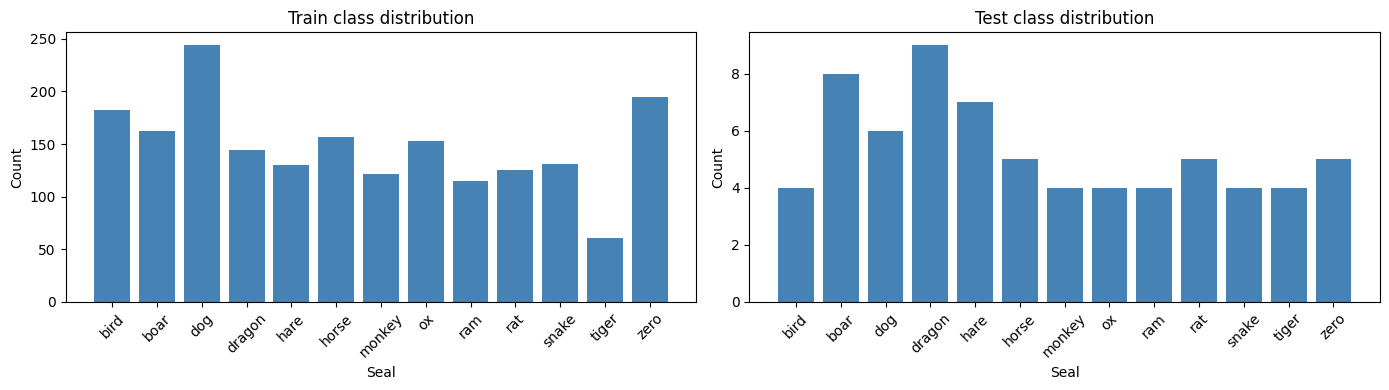

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, y, title in [(axes[0], y_train, "Train"), (axes[1], y_test, "Test")]:
    classes, counts = np.unique(y, return_counts=True)
    ax.bar(classes, counts, color="steelblue")
    ax.set_title(f"{title} class distribution")
    ax.set_xlabel("Seal")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Sanity Check

I0000 00:00:1777303482.751968   35549 gl_context.cc:369] GL version: 2.1 (2.1 ATI-4.14.4), renderer: AMD Radeon Pro 580 OpenGL Engine
W0000 00:00:1777303482.786391  108434 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777303482.818797  108430 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


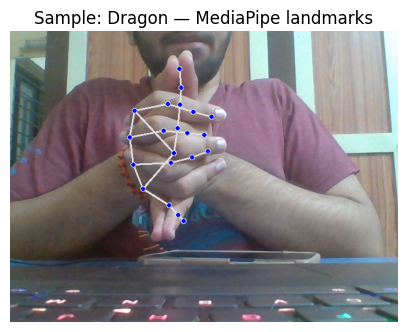

In [14]:
sample_path = next((TRAIN_DIR / "Dragon").glob("*.jpg"))
img = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)

with mp_hands.Hands(static_image_mode=True, max_num_hands=1) as hands:
    result = hands.process(img)

annotated = img.copy()
if result.multi_hand_landmarks:
    mp.solutions.drawing_utils.draw_landmarks(
        annotated,
        result.multi_hand_landmarks[0],
        mp_hands.HAND_CONNECTIONS
    )

plt.figure(figsize=(5, 5))
plt.imshow(annotated)
plt.title("Sample: Dragon — MediaPipe landmarks")
plt.axis("off")
plt.show()

## Training

In [15]:
le = LabelEncoder().fit(SEAL_CLASSES)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=10, gamma="scale", probability=True))
])

pipe.fit(X_train, y_train_enc)

train_acc = accuracy_score(y_train_enc, pipe.predict(X_train))
test_acc  = accuracy_score(y_test_enc,  pipe.predict(X_test))
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}")

Train accuracy: 0.999
Test  accuracy: 0.667


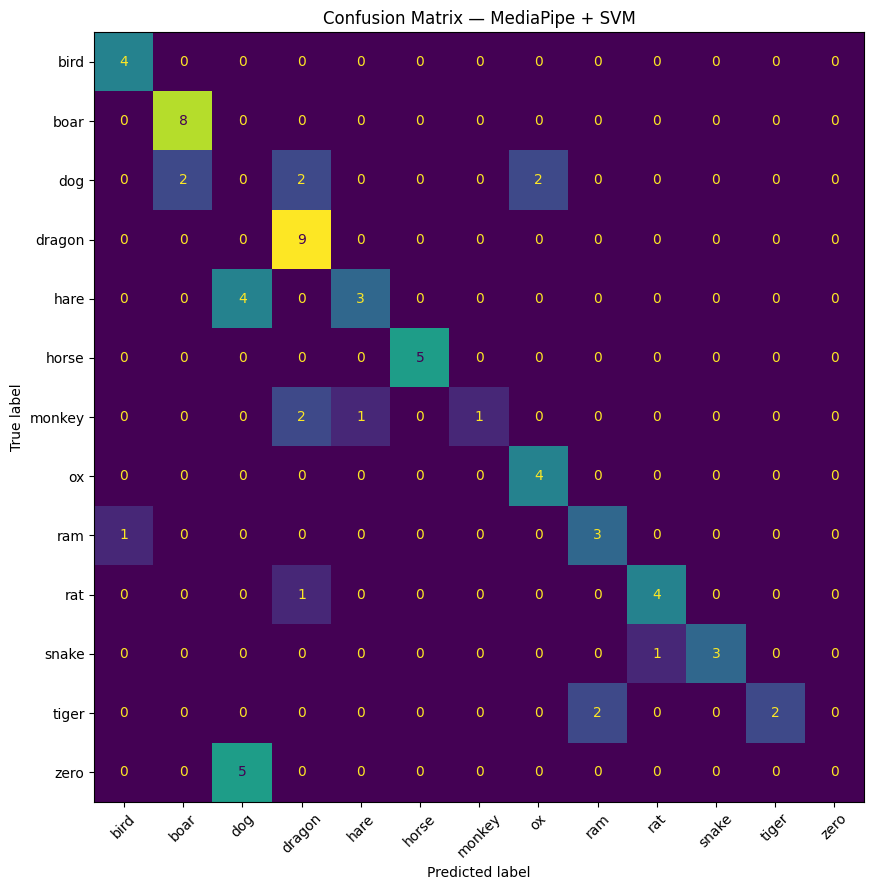

In [16]:
y_pred = pipe.predict(X_test_enc if False else X_test)  # already encoded above
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(11, 9))
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
plt.title("Confusion Matrix — MediaPipe + SVM")
plt.tight_layout()
plt.show()

In [17]:
proba = pipe.predict_proba(X_test)
top3_correct = sum(
    y_test_enc[i] in np.argsort(proba[i])[-3:]
    for i in range(len(y_test_enc))
)
print(f"Top-3 accuracy: {top3_correct / len(y_test_enc):.3f}")

Top-3 accuracy: 0.768


## Live Demo

In [ ]:
cap = cv2.VideoCapture(0)
print("Press Q to quit")

with mp_hands.Hands(static_image_mode=False, max_num_hands=1) as hands:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)
        label = "No hand detected"
        
        if result.multi_hand_landmarks:
            vec = np.array([[p.x, p.y, p.z]
                            for p in result.multi_hand_landmarks[0].landmark]).flatten()
            pred_enc = pipe.predict([vec])[0]
            label = le.inverse_transform([pred_enc])[0]
        
        cv2.putText(frame, label, (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 200, 255), 3)
        cv2.imshow("PoC — Naruto Handsign", frame)
        
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

cap.release()
cv2.destroyAllWindows()

Press Q to quit


I0000 00:00:1777303526.357591   35549 gl_context.cc:369] GL version: 2.1 (2.1 ATI-4.14.4), renderer: AMD Radeon Pro 580 OpenGL Engine
W0000 00:00:1777303526.383575  109249 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777303526.405034  109249 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


: 